---
## 📦 Cell 1 — Import Library

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from keras.utils import to_categorical
from keras.models import Model
from keras.layers import (
    Input, Dense, Dropout, BatchNormalization,
    Bidirectional, LSTM, Layer
)
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.regularizers import l2

PATH_CONFIGURATION_GENERAL = 'Epoch200'

print(f'TensorFlow  : {tf.__version__}')
print(f'Keras       : {tf.keras.__version__}')
print(f'GPU tersedia: {tf.config.list_physical_devices("GPU")}')

TensorFlow  : 2.17.0
Keras       : 3.4.1
GPU tersedia: []


---
## ⚙️ Cell 2 — Konfigurasi

In [2]:
DATA_PATH = '../../DatasetSibiKeypoints'
sequence_length = 45
FITUR_PER_FRAME = 258            # pose(132) + lh(63) + rh(63), TANPA wajah
MODEL_OUTPUT    = f'{PATH_CONFIGURATION_GENERAL}/model5class.keras'       # <-- 1 file output final
TEMP_CHECKPOINT = f'{PATH_CONFIGURATION_GENERAL}/temp_checkpoint.keras'  # file sementara, dihapus otomatis

# 3 kelas training sementara

actions = np.array(['Saya', 'Makan', 'Obat', 'Agar', 'Kuat']);
# Distribusi folder per variasi jarak (referensi)
# Folder 0-168   : jarak 70-80 cm normal
# Folder 169-193 : jarak 70-80 cm lambat
# Folder 194-218 : jarak 70-80 cm cepat
# Folder 219-258 : jarak 50-60 cm normal
# Folder 259-299 : jarak 90-100 cm normal

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Kelas yang dilatih :', actions)
print('Jumlah kelas        :', len(actions))
print('Sequence length     :', sequence_length)
print('Fitur per frame     :', FITUR_PER_FRAME)
print('Output model        :', MODEL_OUTPUT)

os.makedirs(os.path.dirname(MODEL_OUTPUT), exist_ok=True)
os.makedirs(os.path.dirname(TEMP_CHECKPOINT), exist_ok=True)
print('✅ Folder output siap:', os.path.dirname(MODEL_OUTPUT))

Kelas yang dilatih : ['Saya' 'Makan' 'Obat' 'Agar' 'Kuat']
Jumlah kelas        : 5
Sequence length     : 45
Fitur per frame     : 258
Output model        : Epoch200/model5class.keras
✅ Folder output siap: Epoch200


---
## 📂 Cell 3 — Load Dataset & Verifikasi

In [3]:
label_map = {label: num for num, label in enumerate(actions)}
print('Label map:', label_map)

sequences, labels = [], []

for action in actions:
    action_path = os.path.join(DATA_PATH, action)

    if not os.path.exists(action_path):
        print(f'⚠️  Folder tidak ditemukan: {action_path}')
        continue

    sequence_folders = sorted(
        [f for f in os.listdir(action_path) if f.isdigit()],
        key=int
    )

    loaded, skipped = 0, 0
    for sequence in sequence_folders:
        window = []
        try:
            for frame_num in range(sequence_length):
                res = np.load(os.path.join(action_path, sequence, f'{frame_num}.npy'))
                if res.shape[0] != FITUR_PER_FRAME:
                    raise ValueError(f'Fitur {res.shape[0]} != {FITUR_PER_FRAME} — cek extract_keypoints!')
                window.append(res)
            sequences.append(np.array(window))
            labels.append(label_map[action])
            loaded += 1
        except Exception:
            skipped += 1

    print(f'  {action:12s}: {loaded} dimuat, {skipped} dilewati')

X     = np.array(sequences)
y_int = np.array(labels)
y     = to_categorical(y_int, num_classes=len(actions))

print(f'\n✅ Shape X : {X.shape}')  # (N, 45, 258)
print(f'✅ Shape y : {y.shape}')    # (N, 3)
print('\nDistribusi kelas:')
for u, c in zip(*np.unique(y_int, return_counts=True)):
    print(f'  {actions[u]:12s}: {c} sequence')

Label map: {'Saya': 0, 'Makan': 1, 'Obat': 2, 'Agar': 3, 'Kuat': 4}
  Saya        : 300 dimuat, 0 dilewati
  Makan       : 300 dimuat, 0 dilewati
  Obat        : 300 dimuat, 0 dilewati
  Agar        : 300 dimuat, 0 dilewati
  Kuat        : 300 dimuat, 0 dilewati

✅ Shape X : (1500, 45, 258)
✅ Shape y : (1500, 5)

Distribusi kelas:
  Saya        : 300 sequence
  Makan       : 300 sequence
  Obat        : 300 sequence
  Agar        : 300 sequence
  Kuat        : 300 sequence


---
## 🔀 Cell 4 — Augmentasi Data

In [4]:
def augment_sequence(seq):
    """Hasilkan 4 versi augmentasi dari 1 sequence asli."""
    augmented = []

    # 1. Gaussian noise ringan
    augmented.append(seq + np.random.normal(0, 0.01, seq.shape))

    # 2. Scaling (simulasi variasi jarak)
    augmented.append(seq * np.random.uniform(0.93, 1.07))

    # 3. Horizontal flip (simulasi tangan dominan berbeda)
    flipped = seq.copy()
    for fi in range(0, FITUR_PER_FRAME, 3):
        flipped[:, fi] = 1.0 - seq[:, fi]
    augmented.append(flipped)

    # 4. Time warping (simulasi kecepatan berbeda)
    factor  = np.random.uniform(0.85, 1.15)
    old_idx = np.linspace(0, sequence_length - 1, sequence_length)
    new_idx = np.linspace(0, sequence_length - 1, int(sequence_length * factor))
    warped  = np.array([
        np.interp(old_idx, new_idx[:sequence_length],
                  seq[:min(len(new_idx), sequence_length), fi])
        for fi in range(FITUR_PER_FRAME)
    ]).T
    augmented.append(warped)

    return augmented


print('Melakukan augmentasi...')
X_aug_list = list(X)
y_aug_list = list(y_int)

for seq, lbl in zip(X, y_int):
    for aug_seq in augment_sequence(seq):
        X_aug_list.append(aug_seq)
        y_aug_list.append(lbl)

X_aug     = np.array(X_aug_list, dtype=np.float32)
y_aug     = np.array(y_aug_list)
y_aug_cat = to_categorical(y_aug, num_classes=len(actions))

print(f'Sebelum augmentasi : {X.shape[0]} sequence')
print(f'Setelah augmentasi : {X_aug.shape[0]} sequence (5x lipat)')
print('\nDistribusi setelah augmentasi:')
for u, c in zip(*np.unique(y_aug, return_counts=True)):
    print(f'  {actions[u]:12s}: {c} sequence')

Melakukan augmentasi...
Sebelum augmentasi : 1500 sequence
Setelah augmentasi : 7500 sequence (5x lipat)

Distribusi setelah augmentasi:
  Saya        : 1500 sequence
  Makan       : 1500 sequence
  Obat        : 1500 sequence
  Agar        : 1500 sequence
  Kuat        : 1500 sequence


---
## ✂️ Cell 5 — Split Dataset

Train : 5250 (70.0%)
Val   : 1125   (15.0%)
Test  : 1125  (15.0%)


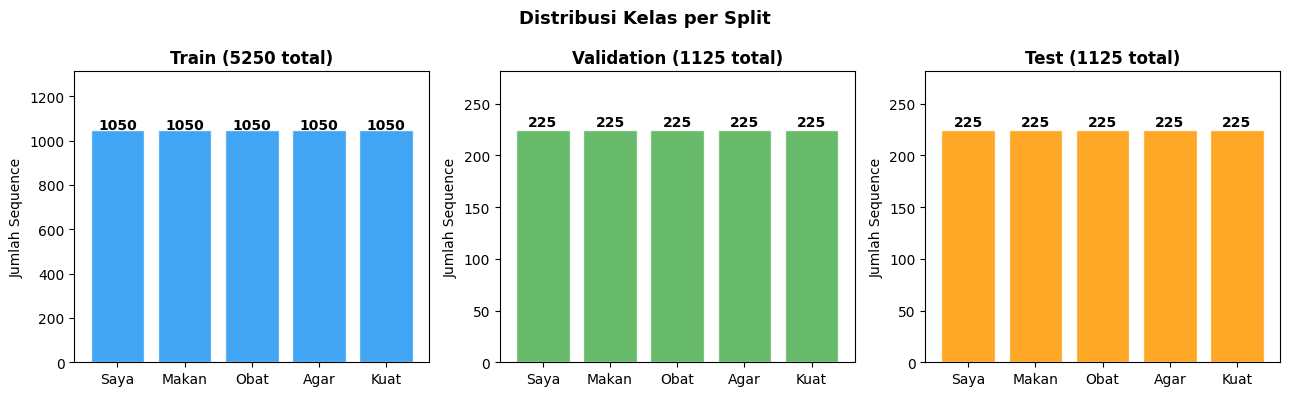

In [5]:
# 70% train | 15% val | 15% test — stratified
X_train, X_temp, y_train, y_temp = train_test_split(
    X_aug, y_aug_cat, test_size=0.30, random_state=SEED, stratify=y_aug
)
y_temp_int = np.argmax(y_temp, axis=1)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp_int
)

print(f'Train : {X_train.shape[0]} ({X_train.shape[0]/X_aug.shape[0]*100:.1f}%)')
print(f'Val   : {X_val.shape[0]}   ({X_val.shape[0]/X_aug.shape[0]*100:.1f}%)')
print(f'Test  : {X_test.shape[0]}  ({X_test.shape[0]/X_aug.shape[0]*100:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, y_s), color in zip(
    axes,
    {'Train': y_train, 'Validation': y_val, 'Test': y_test}.items(),
    ['#2196F3', '#4CAF50', '#FF9800']
):
    counts = np.sum(y_s, axis=0).astype(int)
    bars = ax.bar(actions, counts, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{name} ({y_s.shape[0]} total)', fontweight='bold')
    ax.set_ylabel('Jumlah Sequence')
    ax.set_ylim(0, max(counts) * 1.25)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 3, str(c), ha='center', fontweight='bold')

plt.suptitle('Distribusi Kelas per Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PATH_CONFIGURATION_GENERAL}/plot_distribusi_split.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🧠 Cell 6 — Definisi Model BiLSTM + Attention

In [6]:
class AttentionLayer(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(shape=(input_shape[1], 1),
                                 initializer='zeros', trainable=True)
        super().build(input_shape)

    def call(self, x):
        e = tf.nn.tanh(tf.matmul(x, self.W) + self.b)
        a = tf.nn.softmax(e, axis=1)
        return tf.reduce_sum(x * a, axis=1)

    def get_config(self):
        return super().get_config()


def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        ce     = -y_true * tf.math.log(y_pred)
        pt     = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        return tf.reduce_mean(alpha * tf.pow(1.0 - pt, gamma) * ce)
    return loss_fn


def build_model(seq_len, n_features, n_classes):
    inputs = Input(shape=(seq_len, n_features))

    x = Bidirectional(LSTM(64, return_sequences=True,
                           kernel_regularizer=l2(0.001)))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = Bidirectional(LSTM(64, return_sequences=True,
                           kernel_regularizer=l2(0.001)))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = AttentionLayer()(x)

    x = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.3)(x)

    outputs = Dense(n_classes, activation='softmax')(x)
    return Model(inputs, outputs, name='BiLSTM_Attention_SIBI')


model = build_model(sequence_length, FITUR_PER_FRAME, len(actions))
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)
model.summary()

with open(f'{PATH_CONFIGURATION_GENERAL}/model_summary.txt', 'w', encoding='utf-8') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
print("✅ Model summary tersimpan : model_summary.txt")

Model: "BiLSTM_Attention_SIBI"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 45, 258)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 45, 128)        │       165,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 45, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 45, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 45, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 45, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 45, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 128)            │           173 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,146 (1.05 MB)

 Trainable params: 275,506 (1.05 MB)

 Non-trainable params: 640 (2.50 KB)

✅ Model summary tersimpan : model_summary.txt


---
## 🏋️ Cell 7 — Training

In [7]:
# ModelCheckpoint simpan ke file TEMPORARY selama training
# File ini akan dihapus otomatis setelah training selesai
checkpoint = ModelCheckpoint(
    TEMP_CHECKPOINT,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=0
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

print('Memulai training...\n')
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# ── Load bobot terbaik dari checkpoint ──────────────────────
best_model = tf.keras.models.load_model(
    TEMP_CHECKPOINT,
    custom_objects={'AttentionLayer': AttentionLayer,
                    'loss_fn': focal_loss()}
)

# ── Simpan 1 file final ──────────────────────────────────────
best_model.save(MODEL_OUTPUT)

# ── Hapus file temporary ─────────────────────────────────────
if os.path.exists(TEMP_CHECKPOINT):
    os.remove(TEMP_CHECKPOINT)

print(f'\n✅ Model terbaik disimpan : {MODEL_OUTPUT}')
print(f'   Val accuracy terbaik   : {max(history.history["val_accuracy"])*100:.2f}%')
print(f'   Epoch terbaik          : {np.argmax(history.history["val_accuracy"]) + 1}')

Memulai training...

Epoch 1/200
165/165 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.6691 - loss: 0.7250 - val_accuracy: 0.7093 - val_loss: 0.2207 - learning_rate: 0.0010
Epoch 2/200
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9104 - loss: 0.1546 - val_accuracy: 0.9253 - val_loss: 0.0737 - learning_rate: 0.0010
Epoch 3/200
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.9469 - loss: 0.0547 - val_accuracy: 0.6809 - val_loss: 0.0414 - learning_rate: 0.0010
Epoch 4/200
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.9527 - loss: 0.0246 - val_accuracy: 0.8133 - val_loss: 0.0212 - learning_rate: 0.0010
Epoch 5/200
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.9432 - loss: 0.0136 - val_accuracy: 0.8293 - val_loss: 0.0148 - learning_rate: 0.0010
Epoch 6/200
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9464 - loss: 0.0095 - val_accuracy: 0.6533 - val_loss: 0.0552 - learning_rate: 0.0010
Epoch 7/200
165/165 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step 

---
## 📈 Cell 8 — Kurva Training

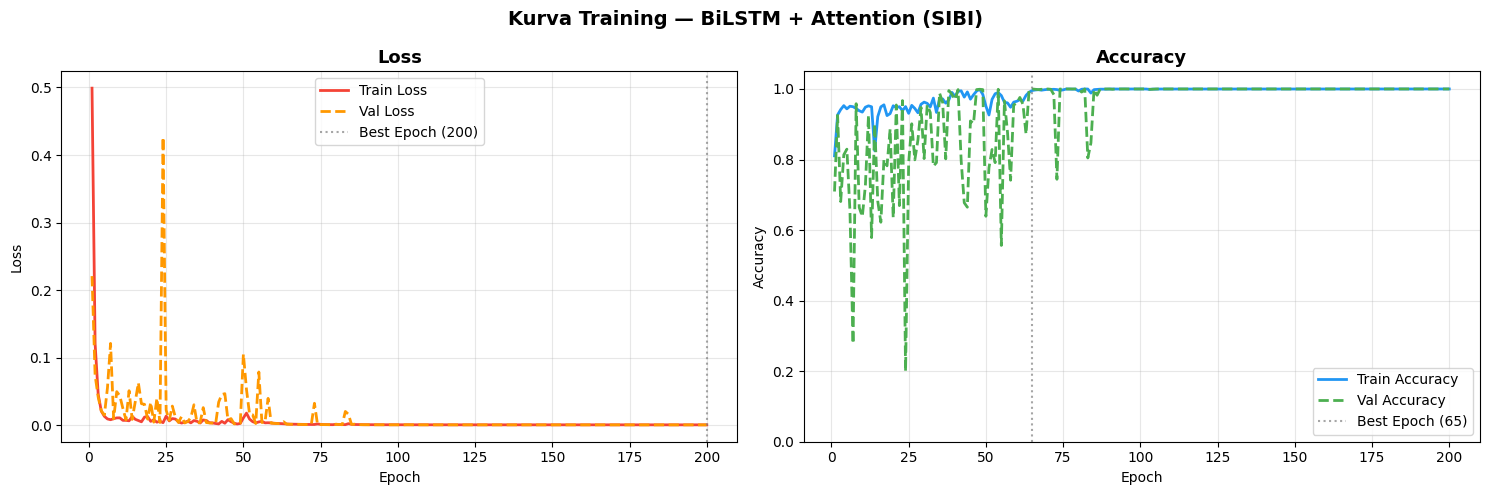

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
epochs_range = range(1, len(history.history['loss']) + 1)

ax = axes[0]
ax.plot(epochs_range, history.history['loss'],
        color='#F44336', linewidth=2, label='Train Loss')
ax.plot(epochs_range, history.history['val_loss'],
        color='#FF9800', linewidth=2, linestyle='--', label='Val Loss')
best_ep = np.argmin(history.history['val_loss']) + 1
ax.axvline(x=best_ep, color='gray', linestyle=':', alpha=0.7,
           label=f'Best Epoch ({best_ep})')
ax.set_title('Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(epochs_range, history.history['accuracy'],
        color='#2196F3', linewidth=2, label='Train Accuracy')
ax.plot(epochs_range, history.history['val_accuracy'],
        color='#4CAF50', linewidth=2, linestyle='--', label='Val Accuracy')
best_ep_acc = np.argmax(history.history['val_accuracy']) + 1
ax.axvline(x=best_ep_acc, color='gray', linestyle=':', alpha=0.7,
           label=f'Best Epoch ({best_ep_acc})')
ax.set_title('Accuracy', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.05)
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Kurva Training — BiLSTM + Attention (SIBI)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PATH_CONFIGURATION_GENERAL}/plot_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🧪 Cell 9 — Evaluasi Test Set

In [9]:
loss, acc = best_model.evaluate(X_test, y_test, verbose=0)
print('=' * 50)
print(f'  TEST ACCURACY : {acc * 100:.2f}%')
print(f'  TEST LOSS     : {loss:.4f}')
print('=' * 50)

y_pred_prob = best_model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = np.argmax(y_test,      axis=1)

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=actions))

# Simpan classification report ke file teks
report_str = classification_report(y_true, y_pred, target_names=actions)
with open(f'{PATH_CONFIGURATION_GENERAL}/classification_report.txt', 'w') as f:
    f.write(f"Test Accuracy : {acc*100:.2f}%\n")
    f.write(f"Test Loss     : {loss:.4f}\n\n")
    f.write(report_str)
print("✅ Classification report tersimpan")

  TEST ACCURACY : 100.00%
  TEST LOSS     : 0.0011

Classification Report:
              precision    recall  f1-score   support

        Saya       1.00      1.00      1.00       225
       Makan       1.00      1.00      1.00       225
        Obat       1.00      1.00      1.00       225
        Agar       1.00      1.00      1.00       225
        Kuat       1.00      1.00      1.00       225

    accuracy                           1.00      1125
   macro avg       1.00      1.00      1.00      1125
weighted avg       1.00      1.00      1.00      1125

✅ Classification report tersimpan


---
## 🔥 Cell 10 — Confusion Matrix

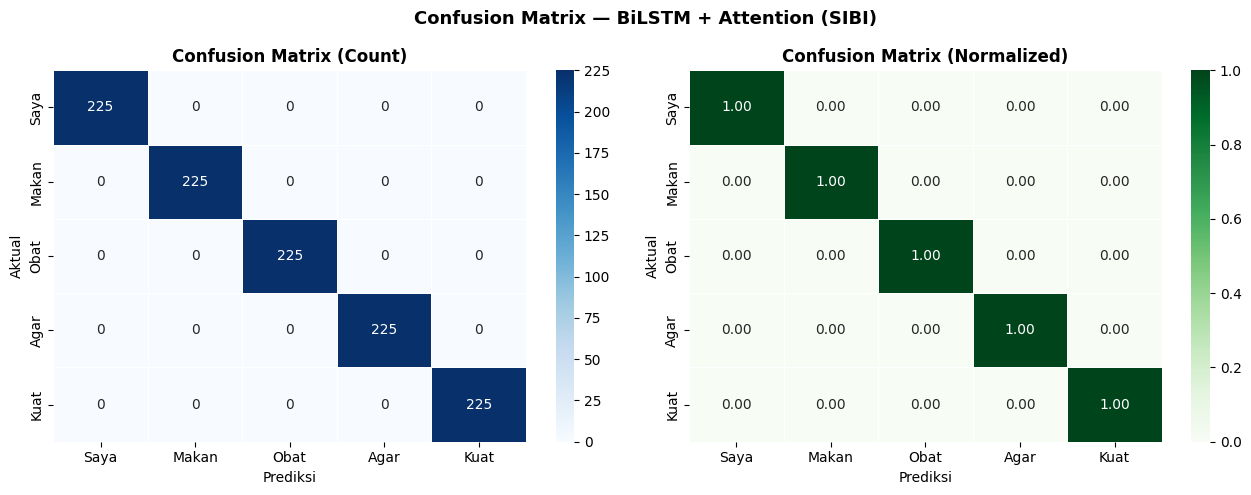


⚠️  Confusable Pairs:


In [10]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=actions, yticklabels=actions, ax=axes[0],
            linewidths=0.5, linecolor='white')
axes[0].set_title('Confusion Matrix (Count)', fontweight='bold')
axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=actions, yticklabels=actions, ax=axes[1],
            linewidths=0.5, linecolor='white', vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_xlabel('Prediksi'); axes[1].set_ylabel('Aktual')

plt.suptitle('Confusion Matrix — BiLSTM + Attention (SIBI)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PATH_CONFIGURATION_GENERAL}/plot_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n⚠️  Confusable Pairs:')
for i in range(len(actions)):
    for j in range(len(actions)):
        if i != j and cm[i][j] > 0:
            print(f'  {actions[i]} → diprediksi {actions[j]}: {cm[i][j]} kali')

---
## 📊 Cell 11 — Per-Class Metrics

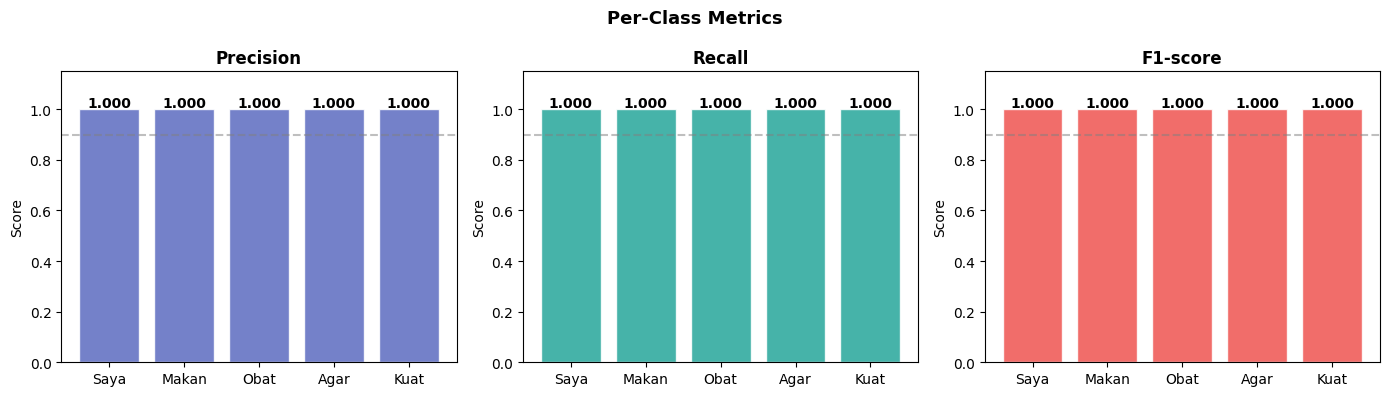

       precision  recall  f1-score  support
Saya         1.0     1.0       1.0    225.0
Makan        1.0     1.0       1.0    225.0
Obat         1.0     1.0       1.0    225.0
Agar         1.0     1.0       1.0    225.0
Kuat         1.0     1.0       1.0    225.0


In [11]:
report    = classification_report(y_true, y_pred,
                                   target_names=actions, output_dict=True)
df_report = pd.DataFrame(report).transpose().loc[actions]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric, color in zip(
    axes,
    ['precision', 'recall', 'f1-score'],
    ['#5C6BC0',   '#26A69A', '#EF5350']
):
    vals = df_report[metric].values
    bars = ax.bar(actions, vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(metric.capitalize(), fontweight='bold')
    ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
    ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Per-Class Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PATH_CONFIGURATION_GENERAL}/plot_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print(df_report[['precision','recall','f1-score','support']].to_string())

---
## 📉 Cell 12 — Confidence Distribution

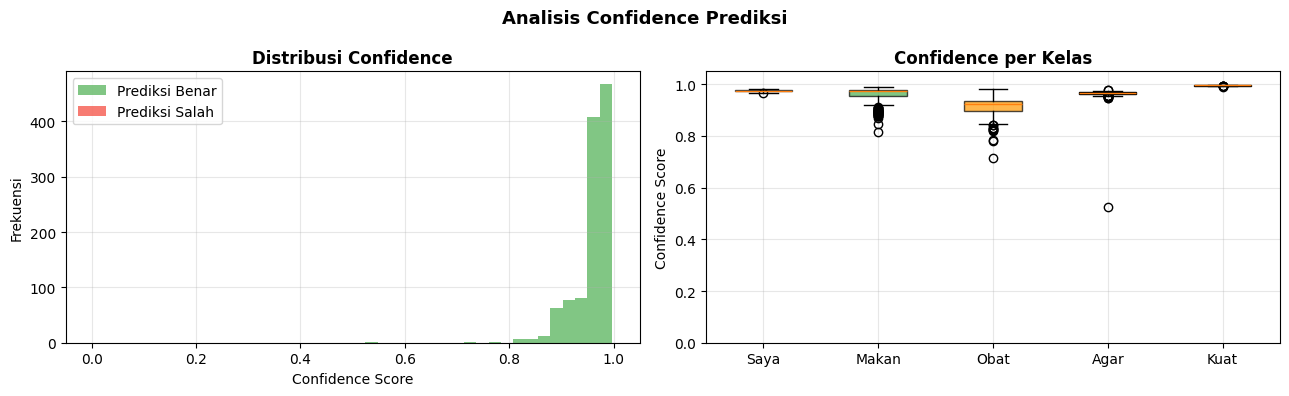

Confidence rata-rata benar : 0.9612
Confidence rata-rata salah : nan


In [12]:
max_conf   = np.max(y_pred_prob, axis=1)
is_correct = (y_pred == y_true)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(max_conf[is_correct],  bins=20, alpha=0.7,
        color='#4CAF50', label='Prediksi Benar')
ax.hist(max_conf[~is_correct], bins=20, alpha=0.7,
        color='#F44336', label='Prediksi Salah')
ax.set_title('Distribusi Confidence', fontweight='bold')
ax.set_xlabel('Confidence Score'); ax.set_ylabel('Frekuensi')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
bp = ax.boxplot(
    [max_conf[y_true == i] for i in range(len(actions))],
    labels=actions, patch_artist=True
)
for patch, c in zip(bp['boxes'], ['#2196F3','#4CAF50','#FF9800']):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_title('Confidence per Kelas', fontweight='bold')
ax.set_ylabel('Confidence Score'); ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)

plt.suptitle('Analisis Confidence Prediksi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PATH_CONFIGURATION_GENERAL}/plot_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Confidence rata-rata benar : {max_conf[is_correct].mean():.4f}')
print(f'Confidence rata-rata salah : {max_conf[~is_correct].mean():.4f}')

---
## 📋 Cell 13 — Ringkasan Akhir

In [13]:
report_full = classification_report(
    y_true, y_pred, target_names=actions, output_dict=True
)

print('=' * 60)
print('        RINGKASAN HASIL TRAINING — SIBI')
print('=' * 60)
print(f'  Arsitektur    : BiLSTM + Attention + Focal Loss')
print(f'  Kelas         : {", ".join(actions)}')
print(f'  Total data    : {X_aug.shape[0]} (setelah augmentasi 5x)')
print(f'  Fitur/frame   : {FITUR_PER_FRAME}')
print(f'  Sequence len  : {sequence_length} frame @ 30fps = 1.5 detik')
print('-' * 60)
print(f'  Train / Val / Test : {X_train.shape[0]} / {X_val.shape[0]} / {X_test.shape[0]}')
print('-' * 60)
print(f'  Test Accuracy : {acc * 100:.2f}%')
print(f'  Test Loss     : {loss:.4f}')
print(f'  Macro F1      : {report_full["macro avg"]["f1-score"]:.4f}')
print(f'  Weighted F1   : {report_full["weighted avg"]["f1-score"]:.4f}')
print('-' * 60)
print('  Per-Class:')
for action in actions:
    r = report_full[action]
    print(f'  {action:12s}  P={r["precision"]:.3f}  '
          f'R={r["recall"]:.3f}  F1={r["f1-score"]:.3f}')
print('=' * 60)
print(f'\n✅ Output model  : {MODEL_OUTPUT}')
print(f'✅ Plot tersimpan :')
print(f'   - plot_distribusi_split.png')
print(f'   - plot_training_curve.png')
print(f'   - plot_confusion_matrix.png')
print(f'   - plot_per_class_metrics.png')
print(f'   - plot_confidence.png')

# ── Simpan Ringkasan Training ke File ───────────────────────
with open(f'{PATH_CONFIGURATION_GENERAL}/ringkasan_training.txt', 'w', encoding='utf-8') as f:
    f.write('=' * 60 + '\n')
    f.write('        RINGKASAN HASIL TRAINING — SIBI\n')
    f.write('=' * 60 + '\n')
    f.write(f'  Arsitektur    : BiLSTM + Attention + Focal Loss\n')
    f.write(f'  Kelas         : {", ".join(actions)}\n')
    f.write(f'  Jumlah Kelas  : {len(actions)}\n')
    f.write(f'  Total data    : {X_aug.shape[0]} (setelah augmentasi 5x)\n')
    f.write(f'  Fitur/frame   : {FITUR_PER_FRAME}\n')
    f.write(f'  Sequence len  : {sequence_length} frame @ 30fps = {sequence_length/30:.1f} detik\n')
    f.write('-' * 60 + '\n')
    f.write(f'  Train / Val / Test : {X_train.shape[0]} / {X_val.shape[0]} / {X_test.shape[0]}\n')
    f.write('-' * 60 + '\n')
    f.write(f'  Test Accuracy : {acc * 100:.2f}%\n')
    f.write(f'  Test Loss     : {loss:.4f}\n')
    f.write(f'  Macro F1      : {report_full["macro avg"]["f1-score"]:.4f}\n')
    f.write(f'  Weighted F1   : {report_full["weighted avg"]["f1-score"]:.4f}\n')
    f.write(f'  Macro P       : {report_full["macro avg"]["precision"]:.4f}\n')
    f.write(f'  Macro R       : {report_full["macro avg"]["recall"]:.4f}\n')
    f.write('-' * 60 + '\n')
    f.write(f'  Epoch terbaik (val_accuracy) : {np.argmax(history.history["val_accuracy"]) + 1}\n')
    f.write(f'  Epoch terbaik (val_loss)     : {np.argmin(history.history["val_loss"]) + 1}\n')
    f.write(f'  Total epoch berjalan         : {len(history.history["loss"])}\n')
    f.write(f'  Val Accuracy terbaik         : {max(history.history["val_accuracy"]) * 100:.2f}%\n')
    f.write(f'  Val Loss terbaik             : {min(history.history["val_loss"]):.4f}\n')
    f.write('-' * 60 + '\n')
    f.write('  Per-Class Metrics:\n')
    f.write(f'  {"Kelas":<14} {"Precision":>10} {"Recall":>10} {"F1-Score":>10} {"Support":>10}\n')
    f.write('  ' + '-' * 50 + '\n')
    for action in actions:
        r = report_full[action]
        f.write(f'  {action:<14} {r["precision"]:>10.4f} {r["recall"]:>10.4f} '
                f'{r["f1-score"]:>10.4f} {int(r["support"]):>10}\n')
    f.write('-' * 60 + '\n')
    f.write('  File Output:\n')
    f.write(f'  - {MODEL_OUTPUT}\n')
    f.write('  Plot:\n')
    f.write('  - plot_distribusi_split.png\n')
    f.write('  - plot_training_curve.png\n')
    f.write('  - plot_confusion_matrix.png\n')
    f.write('  - plot_per_class_metrics.png\n')
    f.write('  - plot_confidence.png\n')
    f.write('=' * 60 + '\n')

print('✅ Ringkasan tersimpan : ringkasan_training.txt')

        RINGKASAN HASIL TRAINING — SIBI
  Arsitektur    : BiLSTM + Attention + Focal Loss
  Kelas         : Saya, Makan, Obat, Agar, Kuat
  Total data    : 7500 (setelah augmentasi 5x)
  Fitur/frame   : 258
  Sequence len  : 45 frame @ 30fps = 1.5 detik
------------------------------------------------------------
  Train / Val / Test : 5250 / 1125 / 1125
------------------------------------------------------------
  Test Accuracy : 100.00%
  Test Loss     : 0.0011
  Macro F1      : 1.0000
  Weighted F1   : 1.0000
------------------------------------------------------------
  Per-Class:
  Saya          P=1.000  R=1.000  F1=1.000
  Makan         P=1.000  R=1.000  F1=1.000
  Obat          P=1.000  R=1.000  F1=1.000
  Agar          P=1.000  R=1.000  F1=1.000
  Kuat          P=1.000  R=1.000  F1=1.000

✅ Output model  : Epoch200/model5class.keras
✅ Plot tersimpan :
   - plot_distribusi_split.png
   - plot_training_curve.png
   - plot_confusion_matrix.png
   - plot_per_class_metrics.png
   -